# Панельная регрессия: Анализ взаимосвязи золота и золотодобывающих индексов

## Методология (на основе научных работ):
- **Petersen (2009)**: В финансовых исследованиях рекомендуется использовать clustered standard errors
- **Cameron & Miller (2015)**: Для панелей с N > T (как в нашем случае) - clustered errors предпочтительны
- **Greene (2012)**: Выбор между FE и RE на основе теста Хаусмана
- **Driscoll & Kraay (1998)**: Для панелей с автокорреляцией и кросс-секционной зависимостью
- **Blundell & Bond (1998)**: System GMM for dynamic panels with endogeneity

## Содержание:
1. Подготовка данных в панельном формате
2. Тесты на стационарность (ADF, KPSS)
3. Проверка мультиколлинеарности (VIF)
4. Базовые панельные модели (Pooled OLS, FE, RE)
5. Диагностика автокорреляции
6. **Вариант A**: Модели с лагами и Driscoll-Kraay ошибками
7. **Вариант B**: System GMM (Blundell-Bond)
8. Сравнение моделей
9. Диагностика лучшей модели
10. Фиксированные эффекты по индексам
11. Итоговые выводы

In [1]:
# Установка необходимых библиотек
# !pip install linearmodels statsmodels pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects, compare
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ============================================
# НАСТРОЙКА: Выбор папки с data
# ============================================

# Измените эту переменную для выбора другой папки
DATA_FOLDER = "data3/"  # Варианты: "data2/", "data3/"

print(f"📁 Используемая папка с data: {DATA_FOLDER}")

# Проверяем существование папки
import os
if not os.path.exists(DATA_FOLDER):
    print(f"⚠️ Папка {DATA_FOLDER} не найдена!")
    print("Доступные папки:")
    for folder in ["data2/", "data3/"]:
        if os.path.exists(folder):
            print(f"  ✅ {folder}")
    raise FileNotFoundError(f"Папка {DATA_FOLDER} не найдена")
else:
    print(f"✅ Папка {DATA_FOLDER} найдена")
    print(f"   Файлов в папке: {len(os.listdir(DATA_FOLDER))}")

📁 Используемая папка с data: data3/
✅ Папка data3/ найдена
   Файлов в папке: 26


## 1. Загрузка данных

### Конфигурация файлов

In [4]:
# Конфигурация файлов с правильными форматами дат
files_config = [
    {"path": "Прошлые данные - Arca Gold Miners.csv", "col_name": "GDM"},
    {"path": "Прошлые данные по XGD.csv", "col_name": "XGD"},
    {"path": "Прошлые данные по GDX.csv", "col_name": "GDX"},
    {"path": "Прошлые данные - FTSE Gold Mines.csv", "col_name": "FTGM"},
    {"path": "Прошлые данные - Philadelphia Gold_Silver.csv", "col_name": "XAU"},
]

# Макро данные
macro_files = [
    {"path": "Прошлые данные - XAU_USD.csv", "col_name": "Gold"},
    {"path": "Прошлые данные - S&P 500.csv", "col_name": "SP500"},
    {"path": "Прошлые данные - Индекс USD.csv", "col_name": "USD"},
    {"path": "Прошлые данные - Фьючерс на нефть Brent.csv", "col_name": "Oil"},
]

def load_data_file(config):
    """Загрузка одного файла данных с автоматическим определением формата"""
    try:
        file_path = os.path.join(DATA_FOLDER, config["path"])
        df = pd.read_csv(file_path)
        
        date_col = None
        price_col = None
        
        for col in df.columns:
            col_lower = col.lower()
            if 'date' in col_lower or 'дата' in col_lower:
                date_col = col
                break
        
        if 'Price' in df.columns:
            price_col = 'Price'
        elif 'Цена' in df.columns:
            price_col = 'Цена'
        else:
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            if len(numeric_cols) > 0:
                price_col = numeric_cols[0]
        
        if date_col is None or price_col is None:
            print(f"  ⚠️ Не удалось определить колонки для {config['col_name']}")
            return None
        
        if date_col == "Date":
            df['Date'] = pd.to_datetime(df[date_col], format='%m/%d/%Y')
        else:
            df['Date'] = pd.to_datetime(df[date_col], format='%d.%m.%Y')
        
        if df[price_col].dtype == 'object':
            df[price_col] = df[price_col].astype(str).str.replace(' ', '', regex=False)
            df[price_col] = df[price_col].str.replace('.', '', regex=False)
            df[price_col] = df[price_col].str.replace(',', '.', regex=False)
            df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
        
        df = df[['Date', price_col]].rename(columns={price_col: config["col_name"]})
        df = df[df['Date'] >= '2003-01-01']
        
        df = df.drop_duplicates(subset=['Date'], keep='first')
        df = df.dropna()
        df = df.sort_values('Date').reset_index(drop=True)
        
        return df
    except Exception as e:
        print(f"Error loading {config['col_name']}: {e}")
        return None

In [5]:
# Загрузка данных
dataframes = {}

for config in files_config:
    df = load_data_file(config)
    if df is not None:
        dataframes[config["col_name"]] = df
        print(f"Loaded {config['col_name']}: {len(df)} records")

for config in macro_files:
    df = load_data_file(config)
    if df is not None:
        dataframes[config["col_name"]] = df
        print(f"Loaded {config['col_name']}: {len(df)} records")

print(f"\nTotal indices loaded: {len(dataframes)}")

# Объединение всех данных по дате
merged_df = None
for name, df in dataframes.items():
    if merged_df is None:
        merged_df = df
    else:
        merged_df = pd.merge(merged_df, df, on='Date', how='outer')

merged_df = merged_df.sort_values('Date').reset_index(drop=True)
print(f"\nTotal merged: {len(merged_df)} records")
print(f"Date range: {merged_df['Date'].min()} - {merged_df['Date'].max()}")

Loaded GDM: 1165 records
Loaded XGD: 1165 records
Loaded GDX: 1036 records
Loaded FTGM: 1165 records
Loaded XAU: 1165 records
Loaded Gold: 1165 records
Loaded SP500: 1165 records
Loaded USD: 1165 records
Loaded Oil: 1165 records

Total indices loaded: 9

Total merged: 1165 records
Date range: 2003-12-07 00:00:00 - 2026-03-29 00:00:00


## 2. Дефлирование: загрузка CPI и переход к реальным переменным

### Методология:
- Используем индекс потребительских цен CPIAUCSL (FRED)
- Forward-fill месячные данные CPI на ежедневную частоту
- Real = Nominal / CPI * 100 (базисный период CPI ≈ 1982-84)
- Все макро-переменные и индексы золотодобытчиков дефлируются

In [6]:
# ============================================
# ДЕФЛИРОВАНИЕ: загрузка CPI и создание реальных переменных
# ============================================
print("="*80)
print("📊 ДЕФЛИРОВАНИЕ НОМИНАЛЬНЫХ ДАННЫХ (CPI — CPIAUCSL)")
print("="*80)

# 1. Загрузка CPI (месячные данные из data3/CPIAUCSL.csv)
cpi_path = os.path.join(DATA_FOLDER, "CPIAUCSL.csv")
cpi_df = pd.read_csv(cpi_path)
cpi_df['Date'] = pd.to_datetime(cpi_df['observation_date'])
cpi_df = cpi_df[['Date', 'CPIAUCSL']].sort_values('Date').reset_index(drop=True)
cpi_df = cpi_df.dropna()
print(f"📊 CPI loaded: {len(cpi_df)} monthly observations")
print(f"   Range: {cpi_df['Date'].min()} to {cpi_df['Date'].max()}")

# 2. Создаем daily Date range и forward-fill monthly CPI на daily
min_date = merged_df['Date'].min()
max_date = merged_df['Date'].max()
daily_dates = pd.date_range(start=min_date, end=max_date, freq='D')
cpi_daily = pd.DataFrame({'Date': daily_dates})
cpi_daily = pd.merge(cpi_daily, cpi_df, on='Date', how='left')
cpi_daily['CPIAUCSL'] = cpi_daily['CPIAUCSL'].ffill()  # forward-fill monthly → daily
print(f"   CPI forward-filled to {len(cpi_daily)} daily observations")

# 3. Присоединяем CPI к merged_df
merged_df = pd.merge(merged_df, cpi_daily[['Date', 'CPIAUCSL']], on='Date', how='left')
merged_df['CPIAUCSL'] = merged_df['CPIAUCSL'].ffill()

# 4. Создаем реальные (дефлированные) цены: Real = Nominal / CPI * 100
price_cols = [col for col in merged_df.columns if col not in ['Date', 'CPIAUCSL']]
real_cols = []
for col in price_cols:
    real_name = f'{col}_real'
    merged_df[real_name] = (merged_df[col] / merged_df['CPIAUCSL']) * 100
    real_cols.append(real_name)

print(f"\n✅ Созданы реальные (дефлированные) ряды: {real_cols}")
print(f"   Формула: Real = Nominal / CPI * 100")
print(f"\n📊 Сравнение последних наблюдений (номинал vs реальный):")
for col in price_cols:
    real_name = f'{col}_real'
    print(f"   {col:8}: nominal={merged_df[col].iloc[-1]:.2f}, real={merged_df[real_name].iloc[-1]:.2f}")

📊 ДЕФЛИРОВАНИЕ НОМИНАЛЬНЫХ ДАННЫХ (CPI — CPIAUCSL)
📊 CPI loaded: 231 monthly observations
   Range: 2007-01-01 00:00:00 to 2026-04-01 00:00:00
   CPI forward-filled to 8149 daily observations

✅ Созданы реальные (дефлированные) ряды: ['GDM_real', 'XGD_real', 'GDX_real', 'FTGM_real', 'XAU_real', 'Gold_real', 'SP500_real', 'USD_real', 'Oil_real']
   Формула: Real = Nominal / CPI * 100

📊 Сравнение последних наблюдений (номинал vs реальный):
   GDM     : nominal=2602.47, real=787.93
   XGD     : nominal=59.70, real=18.07
   GDX     : nominal=97.01, real=29.37
   FTGM    : nominal=5447.52, real=1649.30
   XAU     : nominal=394.00, real=119.29
   Gold    : nominal=4780.09, real=1447.23
   SP500   : nominal=6601.01, real=1998.53
   USD     : nominal=99.49, real=30.12
   Oil     : nominal=100.01, real=30.28


## 3. Расчет доходностей на реальных (дефлированных) ценах

In [7]:
# ============================================
# Расчет доходностей на РЕАЛЬНЫХ ценах
# ============================================
print("="*80)
print("📊 РАСЧЕТ ДОХОДНОСТЕЙ НА РЕАЛЬНЫХ (ДЕФЛИРОВАННЫХ) ЦЕНАХ")
print("="*80)

returns_df = merged_df.copy()

# Доходности для реальных цен индексов золотодобытчиков
for col in real_cols:
    returns_df[f'{col}_ret'] = np.log(merged_df[col]).diff()

# Собираем все доходности (номинальные и реальные)
ret_cols_list = [f'{c}_ret' for c in real_cols]
for col in price_cols:
    ret_cols_list.append(f'{col}_ret')

ret_cols_list = list(set(ret_cols_list))  # уникальные
returns_df = returns_df[['Date'] + [c for c in ret_cols_list if c in returns_df.columns]]

print(f"📊 Размерность после расчета доходностей: {returns_df.shape}")
print(f"Колонки: {list(returns_df.columns)}")

📊 РАСЧЕТ ДОХОДНОСТЕЙ НА РЕАЛЬНЫХ (ДЕФЛИРОВАННЫХ) ЦЕНАХ
📊 Размерность после расчета доходностей: (1165, 10)
Колонки: ['Date', 'GDM_real_ret', 'XAU_real_ret', 'USD_real_ret', 'Gold_real_ret', 'XGD_real_ret', 'FTGM_real_ret', 'Oil_real_ret', 'SP500_real_ret', 'GDX_real_ret']


📊 Корреляционная матрица (доходности):
                GDM_real_ret  XAU_real_ret  USD_real_ret  Gold_real_ret  \
GDM_real_ret           1.000         0.984        -0.481          0.810   
XAU_real_ret           0.984         1.000        -0.478          0.779   
USD_real_ret          -0.481        -0.478         1.000         -0.448   
Gold_real_ret          0.810         0.779        -0.448          1.000   
XGD_real_ret           0.957         0.944        -0.357          0.785   
FTGM_real_ret          0.985         0.966        -0.484          0.803   
Oil_real_ret           0.245         0.276        -0.220          0.166   
SP500_real_ret         0.284         0.334        -0.298          0.074   
GDX_real_ret           0.992         0.983        -0.472          0.805   

                XGD_real_ret  FTGM_real_ret  Oil_real_ret  SP500_real_ret  \
GDM_real_ret           0.957          0.985         0.245           0.284   
XAU_real_ret           0.944          0.966         0.27

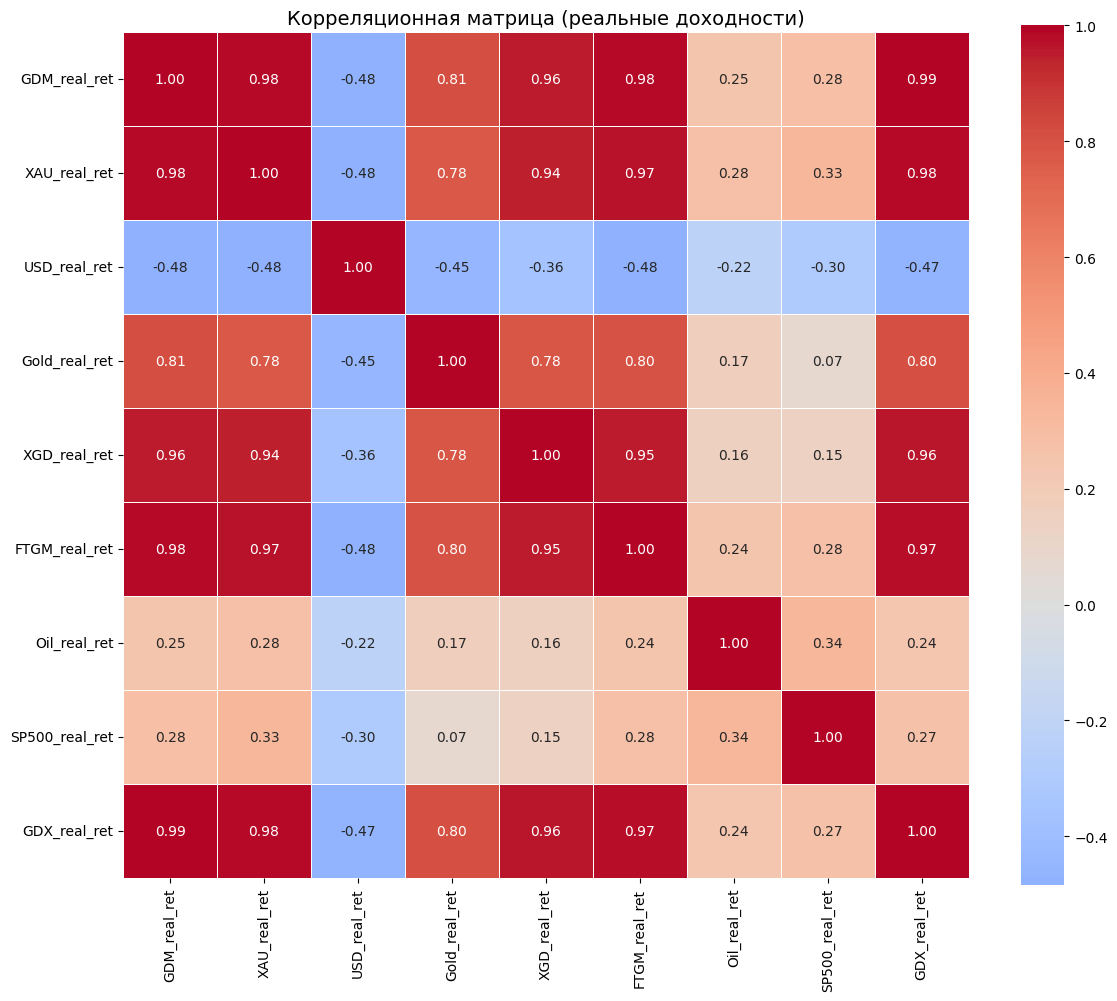

In [8]:
# Корреляционная матрица (сравнение номинальных и реальных доходностей)
ret_cols = [col for col in returns_df.columns if col.endswith('_ret')]
corr_matrix = returns_df[ret_cols].corr()

print("📊 Корреляционная матрица (доходности):")
print(corr_matrix.round(3))

# Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True,
            linewidths=0.5)
plt.title('Корреляционная матрица (реальные доходности)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Преобразование в панельный формат

### Используем реальные (дефлированные) доходности

In [9]:
# Определяем реальные переменные для модели
# Макро-факторы: реальные доходности Gold, SP500, USD, Oil
macro_vars_real = ['Gold_real_ret', 'SP500_real_ret', 'USD_real_ret', 'Oil_real_ret']
# Индексы золотодобытчиков: реальные доходности
mining_indices_real = ['GDM_real_ret', 'XGD_real_ret', 'GDX_real_ret', 'FTGM_real_ret', 'XAU_real_ret']

available_mining = [col for col in mining_indices_real if col in returns_df.columns]
available_macro = [col for col in macro_vars_real if col in returns_df.columns]

print(f"✅ Доступные индексы золотодобытчиков (real): {len(available_mining)}")
print(f"   {available_mining}")
print(f"✅ Доступные макро переменные (real): {len(available_macro)}")
print(f"   {available_macro}")

# Если какие-то реальные переменные отсутствуют — пробуем номинальные
if len(available_macro) < 4:
    print("\n⚠️ Не все реальные макро-переменные найдены, пробуем номинальные...")
    macro_vars_nom = ['Gold_ret', 'SP500_ret', 'USD_ret', 'Oil_ret']
    for v in macro_vars_nom:
        if v not in available_macro and v in returns_df.columns:
            available_macro.append(v)
    print(f"   Доступные макро переменные (fallback): {available_macro}")

if len(available_mining) < 5:
    print("\n⚠️ Не все реальные индексы найдены, пробуем номинальные...")
    mining_indices_nom = ['GDM_ret', 'XGD_ret', 'GDX_ret', 'FTGM_ret', 'XAU_ret']
    for v in mining_indices_nom:
        if v not in available_mining and v in returns_df.columns:
            available_mining.append(v)
    print(f"   Доступные индексы (fallback): {available_mining}")

✅ Доступные индексы золотодобытчиков (real): 5
   ['GDM_real_ret', 'XGD_real_ret', 'GDX_real_ret', 'FTGM_real_ret', 'XAU_real_ret']
✅ Доступные макро переменные (real): 4
   ['Gold_real_ret', 'SP500_real_ret', 'USD_real_ret', 'Oil_real_ret']


In [10]:
# Преобразование в long format
panel_data_list = []

for idx_col in available_mining:
    idx_name = idx_col.replace('_real_ret', '').replace('_ret', '')
    temp_df = returns_df[['Date'] + available_macro + [idx_col]].copy()
    temp_df = temp_df.rename(columns={idx_col: 'Index_Return'})
    temp_df['Index_ID'] = idx_name
    temp_df = temp_df.dropna()
    panel_data_list.append(temp_df)

panel_df = pd.concat(panel_data_list, ignore_index=True)
panel_df = panel_df.set_index(['Index_ID', 'Date'])

print(f"📊 Панельные данные: {panel_df.index.get_level_values(0).nunique()} индексов, {len(panel_df)} наблюдений")

📊 Панельные данные: 5 индексов, 5015 наблюдений


## 5. Тесты на стационарность (ADF и KPSS)

In [11]:
def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Variable': name,
        'ADF_Statistic': result[0],
        'p_value': result[1],
        'Stationary': result[1] < 0.05
    }

def kpss_test(series, name=''):
    try:
        result = kpss(series.dropna(), regression='c', nlags='auto')
        return {
            'Variable': name,
            'KPSS_Statistic': result[0],
            'p_value': result[1],
            'Stationary': result[1] > 0.05
        }
    except:
        return None

print('='*80)
print("📊 ТЕСТЫ НА СТАЦИОНАРНОСТЬ (РЕАЛЬНЫЕ ПЕРЕМЕННЫЕ)")
print("="*80)

adf_results = []
for col in panel_df.columns:
    result = adf_test(panel_df[col], col)
    adf_results.append(result)
    status = "✅" if result['Stationary'] else "❌"
    print(f"{col:20} | p-value: {result['p_value']:.4f} | {status}")

adf_df = pd.DataFrame(adf_results)

stationarity_summary = pd.DataFrame({
    'Variable': adf_df['Variable'],
    'ADF_pvalue': adf_df['p_value'],
    'ADF_Stationary': adf_df['Stationary']
})

all_stationary = stationarity_summary['ADF_Stationary'].all()
print(f"\n📊 Вывод: Все ряды стационарны = {all_stationary}")

📊 ТЕСТЫ НА СТАЦИОНАРНОСТЬ (РЕАЛЬНЫЕ ПЕРЕМЕННЫЕ)
Gold_real_ret        | p-value: 0.0000 | ✅
SP500_real_ret       | p-value: 0.0000 | ✅
USD_real_ret         | p-value: 0.0000 | ✅
Oil_real_ret         | p-value: 0.0000 | ✅
Index_Return         | p-value: 0.0000 | ✅

📊 Вывод: Все ряды стационарны = True


## 6. Проверка мультиколлинеарности (VIF)

In [12]:
print("="*80)
print("📊 ТЕСТ НА МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)")
print("="*80)

X = panel_df[available_macro].dropna()

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n📋 Результаты VIF:")
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] >= 10]
if len(high_vif) > 0:
    print(f"\n⚠️ Переменные с VIF ≥ 10: {high_vif['Variable'].tolist()}")
else:
    print("\n✅ Нет сильной мультиколлинеарности")

📊 ТЕСТ НА МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)

📋 Результаты VIF:
      Variable      VIF
 Gold_real_ret 1.270665
SP500_real_ret 1.209274
  USD_real_ret 1.380476
  Oil_real_ret 1.158866

✅ Нет сильной мультиколлинеарности


## 7. Базовые панельные модели (на реальных данных)

**Методология:**
- Pooled OLS: базовая модель
- Fixed Effects (FE): учитывает индивидуальные эффекты
- Random Effects (RE): альтернативная спецификация
- Используем clustered standard errors (рекомендация для финансовых данных)

**Модель:**
$$IndexReal_{it} = \alpha_i + \beta_1 GoldReal_t + \beta_2 SP500Real_t + \beta_3 USDReal_t + \beta_4 OilReal_t + \varepsilon_{it}$$

In [13]:
# Подготовка данных
dependent = panel_df['Index_Return']
exog = panel_df[available_macro]

print("="*80)
print("📊 OЦЕНКА ПАНЕЛЬНЫХ МОДЕЛЕЙ (РЕАЛЬНЫЕ ПЕРЕМЕННЫЕ)")
print("="*80)

# 1. Pooled OLS
print("\n1️⃣ POOLED OLS")
print("-"*80)
model_pooled = PooledOLS(dependent=dependent, exog=exog)

results_pooled = model_pooled.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
print(results_pooled.summary)

📊 OЦЕНКА ПАНЕЛЬНЫХ МОДЕЛЕЙ (РЕАЛЬНЫЕ ПЕРЕМЕННЫЕ)

1️⃣ POOLED OLS
--------------------------------------------------------------------------------
                          PooledOLS Estimation Summary                          
Dep. Variable:           Index_Return   R-squared:                        0.6775
Estimator:                  PooledOLS   R-squared (Between):             -22.945
No. Observations:                5015   R-squared (Within):               0.6798
Date:                Tue, May 12 2026   R-squared (Overall):              0.6775
Time:                        19:23:24   Log-likelihood                 1.058e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2632.0
Entities:                           5   P-value                           0.0000
Avg Obs:                       1003.0   Distribution:                  F(4,5011)
Min Obs:                       1003.0       

In [14]:
# 2. Fixed Effects
print("\n2️⃣ FIXED EFFECTS (FE)")
print("-"*80)
model_fe = PanelOLS(dependent=dependent, exog=exog, entity_effects=True)
results_fe = model_fe.fit(
    cov_type='kernel',
    kernel='bartlett',
    bandwidth=20
)
print(results_fe.summary)


2️⃣ FIXED EFFECTS (FE)
--------------------------------------------------------------------------------
                          PanelOLS Estimation Summary                           
Dep. Variable:           Index_Return   R-squared:                        0.6799
Estimator:                   PanelOLS   R-squared (Between):             -23.240
No. Observations:                5015   R-squared (Within):               0.6799
Date:                Tue, May 12 2026   R-squared (Overall):              0.6775
Time:                        19:23:24   Log-likelihood                 1.059e+04
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      2657.7
Entities:                           5   P-value                           0.0000
Avg Obs:                       1003.0   Distribution:                  F(4,5006)
Min Obs:                       1003.0                                           
Max 

In [15]:
# 3. Random Effects
print("\n3️⃣ RANDOM EFFECTS (RE)")
print("-"*80)
model_re = RandomEffects(dependent=dependent, exog=exog)
results_re = model_re.fit()
print(results_re.summary)


3️⃣ RANDOM EFFECTS (RE)
--------------------------------------------------------------------------------
                        RandomEffects Estimation Summary                        
Dep. Variable:           Index_Return   R-squared:                        0.6775
Estimator:              RandomEffects   R-squared (Between):             -22.945
No. Observations:                5015   R-squared (Within):               0.6798
Date:                Tue, May 12 2026   R-squared (Overall):              0.6775
Time:                        19:23:24   Log-likelihood                 1.058e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      2632.0
Entities:                           5   P-value                           0.0000
Avg Obs:                       1003.0   Distribution:                  F(4,5011)
Min Obs:                       1003.0                                           
Max

## 8. Диагностика автокорреляции

In [16]:
best_model = results_fe
best_name = "Fixed Effects (real)"

print("="*80)
print(f"📊 ДИАГНОСТИКА АВТОКОРРЕЛЯЦИИ: {best_name}")
print("="*80)

residuals = best_model.resids

print("\n📊 ТЕСТ НА АВТОКОРРЕЛЯЦИЮ (Ljung-Box)")
print("="*80)

for lag in [1, 5, 10, 15]:
    lb_result = acorr_ljungbox(residuals.dropna(), lags=lag, return_df=True)
    lb_stat = lb_result['lb_stat'].iloc[-1]
    lb_pvalue = lb_result['lb_pvalue'].iloc[-1]
    print(f"  Lag {lag}: stat={lb_stat:.4f}, p-value={lb_pvalue:.4f}")
    if lb_pvalue < 0.05:
        print(f"    ⚠️ Автокорреляция обнаружена (p < 0.05)")
    else:
        print(f"    ✅ Автокорреляции нет")

📊 ДИАГНОСТИКА АВТОКОРРЕЛЯЦИИ: Fixed Effects (real)

📊 ТЕСТ НА АВТОКОРРЕЛЯЦИЮ (Ljung-Box)
  Lag 1: stat=30.4903, p-value=0.0000
    ⚠️ Автокорреляция обнаружена (p < 0.05)
  Lag 5: stat=69.5807, p-value=0.0000
    ⚠️ Автокорреляция обнаружена (p < 0.05)
  Lag 10: stat=101.2148, p-value=0.0000
    ⚠️ Автокорреляция обнаружена (p < 0.05)
  Lag 15: stat=136.6352, p-value=0.0000
    ⚠️ Автокорреляция обнаружена (p < 0.05)


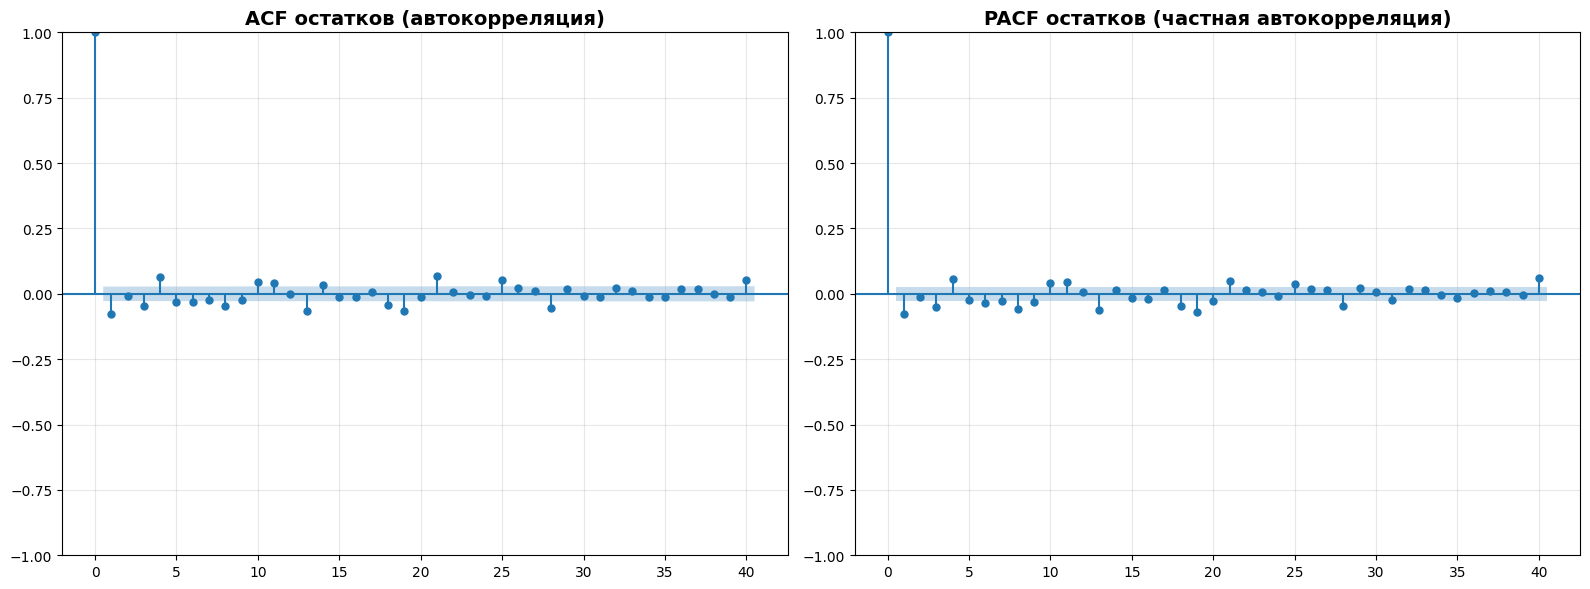


✅ Графики сохранены в 'autocorrelation_diagnostics.png'


In [17]:
# Визуализация ACF/PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_acf(residuals.values, lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF остатков (автокорреляция)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

plot_pacf(residuals.values, lags=40, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF остатков (частная автокорреляция)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('autocorrelation_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Графики сохранены в 'autocorrelation_diagnostics.png'")

In [18]:
# ============================================
# ПРОВЕРКА АВТОКОРРЕЛЯЦИИ ОСТАТКОВ ПО КАЖДОМУ ИНДЕКСУ ОТДЕЛЬНО
# ============================================

print("="*80)
print("🔍 Ljung-Box тест остатков ПО КАЖДОМУ ИНДЕКСУ ОТДЕЛЬНО")
print("="*80)

best_results = results_fe
residuals_fe_check = best_results.resids.reset_index()

significant_lags_count = 0
total_groups = residuals_fe_check['Index_ID'].nunique()

print(f"Всего индексов: {total_groups}\n")

for idx_name, group in residuals_fe_check.groupby('Index_ID'):
    res_group = group['residual'].dropna()
    
    if len(res_group) < 30:
        print(f"{idx_name:6} → слишком мало наблюдений ({len(res_group)})")
        continue
    
    print(f"{idx_name:6} | n = {len(res_group):4d} ", end="")
    
    passes = 0
    for lag in range(1, 41):
        lb = acorr_ljungbox(res_group, lags=lag, return_df=True)
        pval = lb['lb_pvalue'].iloc[-1]
        if pval > 0.05:
            passes += 1
    
    percent_pass = (passes / 40) * 100
    print(f" | Прошло тестов: {passes}/40 ({percent_pass:.0f}%)")
    
    if percent_pass >= 50:
        significant_lags_count += 1

print("\n" + "="*80)
print(f"ИТОГО: {significant_lags_count} из {total_groups} индексов имеют приемлемую автокорреляцию остатков")
print(f"Процент приемлемых уравнений: {(significant_lags_count/total_groups)*100:.1f}%")

🔍 Ljung-Box тест остатков ПО КАЖДОМУ ИНДЕКСУ ОТДЕЛЬНО
Всего индексов: 5

FTGM   | n = 1003  | Прошло тестов: 0/40 (0%)
GDM    | n = 1003  | Прошло тестов: 3/40 (8%)
GDX    | n = 1003  | Прошло тестов: 1/40 (2%)
XAU    | n = 1003  | Прошло тестов: 19/40 (48%)
XGD    | n = 1003  | Прошло тестов: 0/40 (0%)

ИТОГО: 0 из 5 индексов имеют приемлемую автокорреляцию остатков
Процент приемлемых уравнений: 0.0%


## 9. Вариант A: Модели с лагами и Driscoll-Kraay ошибками

### Методология:
- Добавляем лаги зависимой переменной (Lag1-Lag5) для учета динамики
- Используем Driscoll-Kraay стандартные ошибки (kernel HAC) для коррекции автокорреляции
- **Driscoll & Kraay (1998)**: Устойчивы к автокорреляции, гетероскедастичности и кросс-секционной зависимости

In [19]:
# ============================================
# ШАГ 1: Создаём лаги
# ============================================
panel_df = panel_df.sort_values(['Index_ID', 'Date'])

for lag in range(1, 6):
    panel_df[f'Index_Return_Lag{lag}'] = panel_df.groupby('Index_ID')['Index_Return'].shift(lag)

panel_df_clean = panel_df.dropna()
print(f"📊 После добавления лагов: {len(panel_df_clean)} наблюдений")

# ============================================
# ШАГ 2: Функция оценки модели с заданным количеством лагов
# ============================================
def estimate_model_with_lags(lags, bandwidth=12, kernel='bartlett'):
    """
    Оценивает панельную модель с фиксированными эффектами,
    используя Driscoll‑Kraay (kernel HAC) стандартные ошибки.
    """
    lag_vars = [f'Index_Return_Lag{i}' for i in range(1, lags+1)]
    exog_vars = available_macro + lag_vars
    
    panel_used = panel_df_clean.dropna(subset=exog_vars + ['Index_Return'])
    dependent_clean = panel_used['Index_Return']
    exog_clean = panel_used[exog_vars]
    
    model = PanelOLS(dependent=dependent_clean, exog=exog_clean, entity_effects=True)
    results = model.fit(cov_type='kernel', kernel=kernel, bandwidth=bandwidth)
    return results

# ============================================
# ШАГ 3: Оценка нескольких спецификаций
# ============================================
print("\n" + "="*80)
print("📊 МОДЕЛИ С ЛАГАМИ И DRISCOLL‑KRAAY ОШИБКАМИ (РЕАЛЬНЫЕ ДАННЫЕ)")
print("="*80)

results_variants = {}

print("\n📌 Вариант A1: Lag1 + DK(bw=12, bartlett)")
results_variants['A1'] = estimate_model_with_lags(lags=1, bandwidth=12, kernel='bartlett')
print(results_variants['A1'].summary)

print("\n📌 Вариант A2: Lag3 + DK(bw=12, bartlett)")
results_variants['A2'] = estimate_model_with_lags(lags=3, bandwidth=12, kernel='bartlett')
print(results_variants['A2'].summary)

print("\n📌 Вариант A3: Lag5 + DK(bw=20, bartlett)")
results_variants['A3'] = estimate_model_with_lags(lags=5, bandwidth=20, kernel='bartlett')
print(results_variants['A3'].summary)

# ============================================
# ШАГ 4: Сравнение моделей и выбор лучшей
# ============================================
comparison_data = []
for name, res in results_variants.items():
    comparison_data.append({
        'Model': name,
        'R² (within)': res.rsquared_within,
        'R² (overall)': res.rsquared_overall,
        'F-statistic': res.f_statistic.stat,
        'Observations': res.nobs,
        'Parameters': len(res.params)
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n📋 Сводная таблица сравнения:")
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.loc[comparison_df['R² (within)'].idxmax(), 'Model']
best_results_a = results_variants[best_model_name]
print(f"\n✅ Лучшая модель по R² (within): {best_model_name} (R² = {best_results_a.rsquared_within:.4f})")

📊 После добавления лагов: 4990 наблюдений

📊 МОДЕЛИ С ЛАГАМИ И DRISCOLL‑KRAAY ОШИБКАМИ (РЕАЛЬНЫЕ ДАННЫЕ)

📌 Вариант A1: Lag1 + DK(bw=12, bartlett)
                          PanelOLS Estimation Summary                           
Dep. Variable:           Index_Return   R-squared:                        0.6857
Estimator:                   PanelOLS   R-squared (Between):             -28.928
No. Observations:                4990   R-squared (Within):               0.6857
Date:                Tue, May 12 2026   R-squared (Overall):              0.6835
Time:                        19:23:26   Log-likelihood                 1.058e+04
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      2173.3
Entities:                           5   P-value                           0.0000
Avg Obs:                       998.00   Distribution:                  F(5,4980)
Min Obs:                       998.00      

In [20]:
# Дополнительная диагностика лучшей модели
print("\n📊 Дополнительная диагностика:")
print(f"   R² (within)     : {best_results_a.rsquared_within:.4f}")
print(f"   R² (overall)    : {best_results_a.rsquared_overall:.4f}")
print(f"   Количество наблюдений : {best_results_a.nobs}")

# Коэффициенты реальных переменных
for var in available_macro:
    if var in best_results_a.params.index:
        beta = best_results_a.params[var]
        p = best_results_a.pvalues[var]
        print(f"   {var:20}: {beta:.4f} (p = {p:.4f})")


📊 Дополнительная диагностика:
   R² (within)     : 0.6862
   R² (overall)    : 0.6839
   Количество наблюдений : 4990
   Gold_real_ret       : 1.6587 (p = 0.0000)
   SP500_real_ret      : 0.3701 (p = 0.0000)
   USD_real_ret        : -0.2953 (p = 0.0263)
   Oil_real_ret        : 0.0355 (p = 0.0924)


In [21]:
from statsmodels.tsa.stattools import grangercausalitytests
from scipy.stats import chi2

def panel_granger_causality(panel_df, y_var, x_var, entity_col='Index_ID', time_col='Date', max_lag=4):
    """Панельный тест Грейнджера (метод Фишера)."""
    entities = panel_df.index.get_level_values(entity_col).unique()
    pvals = {lag: [] for lag in range(1, max_lag+1)}
    
    for ent in entities:
        unit_data = panel_df.xs(ent, level=entity_col)[[y_var, x_var]].dropna()
        if len(unit_data) > max_lag + 10:
            try:
                res = grangercausalitytests(unit_data[[y_var, x_var]], maxlag=max_lag, verbose=False)
                for lag in range(1, max_lag+1):
                    p = res[lag][0]['ssr_ftest'][1]
                    pvals[lag].append(p)
            except:
                continue
    
    results = {}
    for lag in pvals:
        if len(pvals[lag]) > 0:
            fisher_stat = -2 * np.sum(np.log(pvals[lag]))
            df = 2 * len(pvals[lag])
            p_combined = 1 - chi2.cdf(fisher_stat, df)
            results[lag] = p_combined
    return results

# Используем реальную доходность золота
gold_real_ret = 'Gold_real_ret' if 'Gold_real_ret' in panel_df.columns else 'Gold_ret'
granger_res = panel_granger_causality(panel_df, y_var='Index_Return', x_var=gold_real_ret,
                                      max_lag=4)
print(f"\n📊 Тест Грейнджера: {gold_real_ret} → Index_Return")
for lag, pval in granger_res.items():
    print(f"Lag {lag}: p-value = {pval:.4f} → {'влияние есть' if pval<0.05 else 'нет влияния'}")


📊 Тест Грейнджера: Gold_real_ret → Index_Return
Lag 1: p-value = 0.0007 → влияние есть
Lag 2: p-value = 0.0000 → влияние есть
Lag 3: p-value = 0.0000 → влияние есть
Lag 4: p-value = 0.0000 → влияние есть


## 10. Вариант B: System GMM (Blundell-Bond)

In [22]:
# Проверяем доступность linearmodels для GMM
try:
    from linearmodels.panel import GMM
    print("✅ linearmodels.supports GMM")
except ImportError:
    print("⚠️ linearmodels не поддерживает GMM напрямую")
    print("   Будем использовать альтернативный подход с instrumented regression")

⚠️ linearmodels не поддерживает GMM напрямую
   Будем использовать альтернативный подход с instrumented regression


In [23]:
# ============================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ IV
# ============================================
print("="*80)
print("📊 ОЦЕНКА МОДЕЛИ С ИНСТРУМЕНТАЛЬНЫМИ ПЕРЕМЕННЫМИ (2SLS + FE)")
print("="*80)

# Используем реальные переменные для IV
panel_gmm = panel_df_clean.copy()

# Лаги реальной доходности золота
actual_gold_ret = 'Gold_real_ret' if 'Gold_real_ret' in panel_gmm.columns else 'Gold_ret'
panel_gmm['Gold_ret_lag1'] = panel_gmm.groupby('Index_ID')[actual_gold_ret].shift(1)
panel_gmm['Gold_ret_lag2'] = panel_gmm.groupby('Index_ID')[actual_gold_ret].shift(2)
panel_gmm['Gold_ret_lag3'] = panel_gmm.groupby('Index_ID')[actual_gold_ret].shift(3)

actual_oil_ret = 'Oil_real_ret' if 'Oil_real_ret' in panel_gmm.columns else 'Oil_ret'
panel_gmm['Oil_ret_lag1'] = panel_gmm.groupby('Index_ID')[actual_oil_ret].shift(1)

panel_gmm = panel_gmm.dropna()
print(f"Наблюдений после создания лагов: {len(panel_gmm)}")

# Определяем переменные (реальные)
exog_vars = []
for v in ['SP500_real_ret', 'USD_real_ret', 'Oil_real_ret', 'SP500_ret', 'USD_ret', 'Oil_ret']:
    if v in panel_gmm.columns and v not in exog_vars:
        exog_vars.append(v)
        if len(exog_vars) >= 3:
            break

endog_vars = [actual_gold_ret]
instrument_vars = ['Gold_ret_lag1', 'Gold_ret_lag2', 'Gold_ret_lag3', 'Oil_ret_lag1']

print(f"Экзогенные: {exog_vars}")
print(f"Эндогенные: {endog_vars}")
print(f"Инструменты: {instrument_vars}")

# ============================================
# ДЕМИНГИРОВАНИЕ (WITHIN TRANSFORMATION) ДЛЯ FE
# ============================================
def within_transform(df, vars_list):
    df_dem = df.copy()
    for var in vars_list:
        group_mean = df.groupby('Index_ID')[var].transform('mean')
        df_dem[var] = df[var] - group_mean
    return df_dem

all_vars = ['Index_Return'] + exog_vars + endog_vars + instrument_vars
panel_dem = within_transform(panel_gmm, all_vars)

# ============================================
# ОЦЕНКА IV2SLS НА ДЕМИНГИРОВАННЫХ ДАННЫХ
# ============================================
from linearmodels.iv import IV2SLS

model_iv = IV2SLS(
    dependent=panel_dem['Index_Return'],
    exog=sm.add_constant(panel_dem[exog_vars]),
    endog=panel_dem[endog_vars],
    instruments=panel_dem[instrument_vars]
)
results_iv = model_iv.fit(cov_type='robust')
print("\n" + "="*80)
print("РЕЗУЛЬТАТЫ IV2SLS С ФИКСИРОВАННЫМИ ЭФФЕКТАМИ (РЕАЛЬНЫЕ ПЕРЕМЕННЫЕ)")
print("="*80)
print(results_iv.summary)

# ============================================
# ТЕСТ НА СИЛУ ИНСТРУМЕНТОВ
# ============================================
print("\n" + "="*80)
print("📊 ТЕСТ НА СИЛУ ИНСТРУМЕНТОВ")
print("="*80)

first_stage_data = panel_dem.copy()
first_stage_data['const'] = 1
first_stage_model = sm.OLS(first_stage_data[actual_gold_ret], 
                           first_stage_data[['const'] + exog_vars + instrument_vars])
first_stage_res = first_stage_model.fit()

hypothesis = ' = 0 '.join(instrument_vars)
wald_test = first_stage_res.wald_test(hypothesis)
f_stat = wald_test.fvalue
f_pval = wald_test.pvalue

print(f"F-статистика (исключая инструменты): {f_stat:.2f}")
print(f"p-value: {f_pval:.4f}")
if f_stat > 10:
    print("✅ Инструменты сильные (F > 10)")
else:
    print("⚠️ Слабые инструменты (F < 10)")

# ============================================
# ТЕСТ НА СВЕРХИДЕНТИФИКАЦИЮ (J-ТЕСТ САРГАНА)
# ============================================
print("\n" + "="*80)
print("📊 ТЕСТ САРГАНА (J-статистика)")
print("="*80)

resid_iv = results_iv.resids
Z = np.column_stack([panel_dem[exog_vars], panel_dem[instrument_vars]])
Z = sm.add_constant(Z)
aux_reg = sm.OLS(resid_iv, Z).fit()
n = len(resid_iv)
j_stat = n * aux_reg.rsquared
df_j = len(instrument_vars) - len(endog_vars)
j_pval = 1 - stats.chi2.cdf(j_stat, df_j)

print(f"J-статистика: {j_stat:.4f}")
print(f"Степени свободы: {df_j}")
print(f"p-value: {j_pval:.4f}")
if j_pval > 0.05:
    print("✅ Инструменты валидны (не отвергаем H₀ сверхидентификации)")
else:
    print("⚠️ Инструменты могут быть невалидны (p-value < 0.05)")

# ============================================
# ТЕСТ ХАУСМАНА (FE vs IV)
# ============================================
print("\n" + "="*80)
print("📊 ТЕСТ ХАУСМАНА (FE vs IV)")
print("="*80)

model_fe_simple = PanelOLS(panel_dem['Index_Return'], 
                           exog=sm.add_constant(panel_dem[exog_vars + endog_vars]),
                           entity_effects=False)
res_fe_simple = model_fe_simple.fit(cov_type='robust')

beta_iv = results_iv.params[[actual_gold_ret]]
beta_fe = res_fe_simple.params[[actual_gold_ret]]
cov_iv = results_iv.cov[[actual_gold_ret], [actual_gold_ret]]
cov_fe = res_fe_simple.cov[[actual_gold_ret], [actual_gold_ret]]

diff = beta_iv - beta_fe
cov_diff = cov_iv - cov_fe
hausman_stat = diff.T @ np.linalg.inv(cov_diff) @ diff
hausman_p = 1 - stats.chi2.cdf(hausman_stat, df=1)

print(f"Статистика Хаусмана: {hausman_stat:.4f}")
print(f"p-value: {hausman_p:.4f}")
if hausman_p < 0.05:
    print("✅ Отвергаем экзогенность → инструменты необходимы.")
else:
    print("❌ Не отвергаем экзогенность → можно использовать обычную FE.")

📊 ОЦЕНКА МОДЕЛИ С ИНСТРУМЕНТАЛЬНЫМИ ПЕРЕМЕННЫМИ (2SLS + FE)
Наблюдений после создания лагов: 4975
Экзогенные: ['SP500_real_ret', 'USD_real_ret', 'Oil_real_ret']
Эндогенные: ['Gold_real_ret']
Инструменты: ['Gold_ret_lag1', 'Gold_ret_lag2', 'Gold_ret_lag3', 'Oil_ret_lag1']

РЕЗУЛЬТАТЫ IV2SLS С ФИКСИРОВАННЫМИ ЭФФЕКТАМИ (РЕАЛЬНЫЕ ПЕРЕМЕННЫЕ)
                          IV-2SLS Estimation Summary                          
Dep. Variable:           Index_Return   R-squared:                      0.6793
Estimator:                    IV-2SLS   Adj. R-squared:                 0.6790
No. Observations:                4975   F-statistic:                    2189.1
Date:                Tue, May 12 2026   P-value (F-stat)                0.0000
Time:                        19:23:26   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                            

PatsyError: expected an operator, not 'Gold_ret_lag2'
    Gold_ret_lag1 = 0 Gold_ret_lag2 = 0 Gold_ret_lag3 = 0 Oil_ret_lag1
                      ^^^^^^^^^^^^^

## 11. Asymmetric Response Model (Регрессия с dummy-переменной)

### Модель асимметричной реакции на изменения реальной цены золота

$$R_{it} = \alpha_i + \beta_1 GoldReal_t + \beta_2 (GoldReal_t \times Neg_t) + \beta_3 X_t + \varepsilon_{it}$$

Где:
- $Neg_t = 1$, если $GoldReal_t < 0$ (отрицательное изменение реальной цены золота), иначе 0
- $\beta_1$ — реакция на положительное изменение реальной цены золота
- $\beta_1 + \beta_2$ — реакция на отрицательное изменение реальной цены золота

### Гипотеза:
- $H_0: \beta_2 = 0$ (асимметрии нет)
- $H_1: \beta_2 \neq 0$ (асимметрия присутствует)

In [24]:
# ============================================
# ШАГ 1: Создание переменных асимметрии (на реальных данных)
# ============================================
print("="*80)
print("📊 ASYMMETRIC RESPONSE MODEL (РЕАЛЬНЫЕ ДАННЫЕ)")
print("="*80)

# Определяем, какую переменную используем
gold_var = 'Gold_real_ret' if 'Gold_real_ret' in panel_df.columns else 'Gold_ret'
print(f"\nИспользуемая переменная золота: {gold_var}")

# Создаём дамми-переменную для отрицательной реальной доходности золота
panel_df['Neg_Gold'] = (panel_df[gold_var] < 0).astype(int)

# Создаём раздельные переменные для положительной и отрицательной доходности
panel_df['Gold_pos'] = panel_df[gold_var] * (1 - panel_df['Neg_Gold'])
panel_df['Gold_neg'] = panel_df[gold_var] * panel_df['Neg_Gold']

# Статистика
n_neg = panel_df['Neg_Gold'].sum()
n_pos = len(panel_df) - n_neg
print(f"\n📊 Распределение дней с изменением реальной цены золота:")
print(f"   Положительные дни ({gold_var} >= 0): {n_pos} ({n_pos/len(panel_df)*100:.1f}%)")
print(f"   Отрицательные дни ({gold_var} < 0):  {n_neg} ({n_neg/len(panel_df)*100:.1f}%)")

📊 ASYMMETRIC RESPONSE MODEL (РЕАЛЬНЫЕ ДАННЫЕ)

Используемая переменная золота: Gold_real_ret

📊 Распределение дней с изменением реальной цены золота:
   Положительные дни (Gold_real_ret >= 0): 2705 (53.9%)
   Отрицательные дни (Gold_real_ret < 0):  2310 (46.1%)


In [25]:
# ============================================
# ШАГ 2: Симметричная модель (базовая FE)
# ============================================
print("="*80)
print("📊 СИММЕТРИЧНАЯ МОДЕЛЬ (FE на реальных данных)")
print("="*80)

dependent = panel_df['Index_Return']
exog_sym = panel_df[available_macro]

model_fe_sym = PanelOLS(dependent=dependent, exog=exog_sym, entity_effects=True)
results_fe_sym = model_fe_sym.fit(
    cov_type='kernel',
    kernel='bartlett',
    bandwidth=20
)
print(results_fe_sym.summary)

📊 СИММЕТРИЧНАЯ МОДЕЛЬ (FE на реальных данных)
                          PanelOLS Estimation Summary                           
Dep. Variable:           Index_Return   R-squared:                        0.6799
Estimator:                   PanelOLS   R-squared (Between):             -23.240
No. Observations:                5015   R-squared (Within):               0.6799
Date:                Tue, May 12 2026   R-squared (Overall):              0.6775
Time:                        22:24:56   Log-likelihood                 1.059e+04
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      2657.7
Entities:                           5   P-value                           0.0000
Avg Obs:                       1003.0   Distribution:                  F(4,5006)
Min Obs:                       1003.0                                           
Max Obs:                       1003.0   F-statistic (robust):  

In [26]:
# ============================================
# ШАГ 3: Асимметричная модель (с Gold_pos и Gold_neg)
# ============================================
print("="*80)
print("📊 АСИММЕТРИЧНАЯ МОДЕЛЬ (FE с разделением Gold_pos/Gold_neg)")
print("="*80)

# Вместо gold_var используем Gold_pos и Gold_neg
asym_vars = ['Gold_pos', 'Gold_neg'] + [v for v in available_macro if v != gold_var]
print(f"Переменные в асимметричной модели: {asym_vars}")

exog_asym = panel_df[asym_vars]

model_fe_asym = PanelOLS(dependent=dependent, exog=exog_asym, entity_effects=True)
results_fe_asym = model_fe_asym.fit(
    cov_type='kernel',
    kernel='bartlett',
    bandwidth=20
)
print(results_fe_asym.summary)

📊 АСИММЕТРИЧНАЯ МОДЕЛЬ (FE с разделением Gold_pos/Gold_neg)
Переменные в асимметричной модели: ['Gold_pos', 'Gold_neg', 'SP500_real_ret', 'USD_real_ret', 'Oil_real_ret']
                          PanelOLS Estimation Summary                           
Dep. Variable:           Index_Return   R-squared:                        0.6801
Estimator:                   PanelOLS   R-squared (Between):             -8.8759
No. Observations:                5015   R-squared (Within):               0.6801
Date:                Tue, May 12 2026   R-squared (Overall):              0.6792
Time:                        22:24:56   Log-likelihood                  1.06e+04
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      2128.1
Entities:                           5   P-value                           0.0000
Avg Obs:                       1003.0   Distribution:                  F(5,5005)
Min Obs:            

📊 СРАВНЕНИЕ КОЭФФИЦИЕНТОВ И ТЕСТ НА АСИММЕТРИЮ

📋 Сравнение коэффициентов:
--------------------------------------------------------------------------------
Параметр                            Коэфф      Стд.ош     p-value    Значимость
--------------------------------------------------------------------------------
Sym. Model: Gold_real (β₁)          1.6503     0.0746     0.0000     ***       
Asym. Model: Gold_pos (β₁)          1.5986     0.0898     0.0000     ***       
Asym. Model: Gold_neg (β₂)          1.7026     0.1266     0.0000     ***       
--------------------------------------------------------------------------------

📊 ТЕСТ НА АСИММЕТРИЮ H₀: β_pos = β_neg (β₂ = 0)

📋 Коэффициенты асимметричной модели (split-спецификация):
   β_pos (Gold_pos, реакция на рост):     1.5986 (p = 0.0000)
   β_neg (Gold_neg, реакция на падение):   1.7026 (p = 0.0000)

📊 РЕЗУЛЬТАТЫ ТЕСТА:
------------------------------------------------------------
   β_pos - β_neg = -0.1040
   SE(β_pos - β_neg)

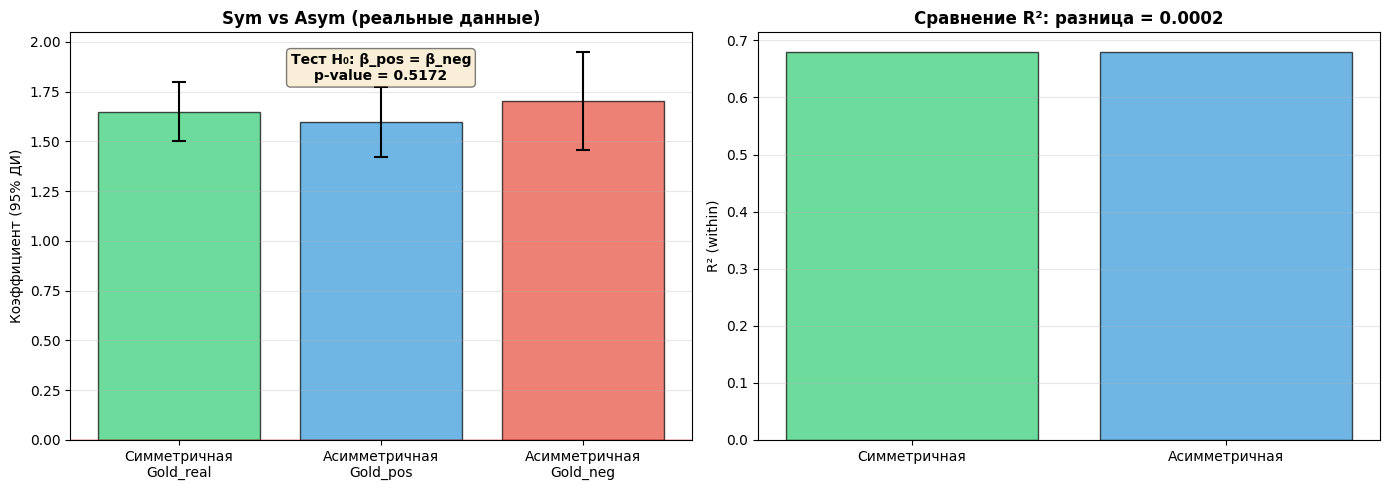


✅ График сохранен в 'asymmetry_real.png'


In [28]:
# ============================================
# ШАГ 4: Сравнение коэффициентов и тест асимметрии
# ============================================
print("="*80)
print("📊 СРАВНЕНИЕ КОЭФФИЦИЕНТОВ И ТЕСТ НА АСИММЕТРИЮ")
print("="*80)

# Извлекаем коэффициенты
beta_gold_sym = results_fe_sym.params[gold_var]
p_gold_sym = results_fe_sym.pvalues[gold_var]
se_gold_sym = results_fe_sym.std_errors[gold_var]

beta_gold_pos = results_fe_asym.params['Gold_pos']
p_gold_pos = results_fe_asym.pvalues['Gold_pos']
se_gold_pos = results_fe_asym.std_errors['Gold_pos']

beta_gold_neg = results_fe_asym.params['Gold_neg']
p_gold_neg = results_fe_asym.pvalues['Gold_neg']
se_gold_neg = results_fe_asym.std_errors['Gold_neg']

print("\n📋 Сравнение коэффициентов:")
print("-"*80)
print(f"{'Параметр':<35} {'Коэфф':<10} {'Стд.ош':<10} {'p-value':<10} {'Значимость':<10}")
print("-"*80)

sym_stars = "***" if p_gold_sym < 0.01 else "**" if p_gold_sym < 0.05 else "*" if p_gold_sym < 0.1 else ""
print(f"{'Sym. Model: Gold_real (β₁)':<35} {beta_gold_sym:<10.4f} {se_gold_sym:<10.4f} {p_gold_sym:<10.4f} {sym_stars:<10}")

pos_stars = "***" if p_gold_pos < 0.01 else "**" if p_gold_pos < 0.05 else "*" if p_gold_pos < 0.1 else ""
neg_stars = "***" if p_gold_neg < 0.01 else "**" if p_gold_neg < 0.05 else "*" if p_gold_neg < 0.1 else ""
print(f"{'Asym. Model: Gold_pos (β₁)':<35} {beta_gold_pos:<10.4f} {se_gold_pos:<10.4f} {p_gold_pos:<10.4f} {pos_stars:<10}")
print(f"{'Asym. Model: Gold_neg (β₂)':<35} {beta_gold_neg:<10.4f} {se_gold_neg:<10.4f} {p_gold_neg:<10.4f} {neg_stars:<10}")

print("-"*80)

# ============================================
# Тест на асимметрию: H0: β_pos = β_neg
# ============================================
print("\n" + "="*80)
print("📊 ТЕСТ НА АСИММЕТРИЮ H₀: β_pos = β_neg (β₂ = 0)")
print("="*80)

print(f"\n📋 Коэффициенты асимметричной модели (split-спецификация):")
print(f"   β_pos (Gold_pos, реакция на рост):     {beta_gold_pos:.4f} (p = {p_gold_pos:.4f})")
print(f"   β_neg (Gold_neg, реакция на падение):   {beta_gold_neg:.4f} (p = {p_gold_neg:.4f})")

# Разница коэффициентов
from scipy.stats import t as t_dist
coef_diff = beta_gold_pos - beta_gold_neg
se_diff = np.sqrt(se_gold_pos**2 + se_gold_neg**2 - 2 * results_fe_asym.cov.loc['Gold_pos', 'Gold_neg'])
t_diff = coef_diff / se_diff
p_diff = 2 * (1 - t_dist.cdf(abs(t_diff), results_fe_asym.df_resid))

# Wald тест
wald_stat_asym = coef_diff**2 / se_diff**2
wald_pval_asym = 1 - stats.chi2.cdf(wald_stat_asym, df=1)

print(f"\n📊 РЕЗУЛЬТАТЫ ТЕСТА:")
print("-"*60)
print(f"   β_pos - β_neg = {coef_diff:.4f}")
print(f"   SE(β_pos - β_neg) = {se_diff:.4f}")
print(f"   t-статистика = {t_diff:.4f}")
print(f"   p-value (t-тест) = {p_diff:.6f}")
print(f"   Wald χ²(1) = {wald_stat_asym:.4f}")
print(f"   p-value (Wald) = {wald_pval_asym:.6f}")

asym_pval = min(p_diff, wald_pval_asym)
if asym_pval < 0.01:
    print("\n✅ АСИММЕТРИЯ СТАТИСТИЧЕСКИ ЗНАЧИМА НА УРОВНЕ 1%")
    print(f"   Отвергаем H₀: β_pos = β_neg (p = {asym_pval:.6f})")
    print("   → Реакция на рост и падение реальной цены золота РАЗЛИЧАЕТСЯ")
elif asym_pval < 0.05:
    print("\n✅ АСИММЕТРИЯ СТАТИСТИЧЕСКИ ЗНАЧИМА НА УРОВНЕ 5%")
    print(f"   Отвергаем H₀: β_pos = β_neg (p = {asym_pval:.6f})")
    print("   → Реакция на рост и падение реальной цены золота РАЗЛИЧАЕТСЯ")
elif asym_pval < 0.10:
    print("\n⚠️ АСИММЕТРИЯ ЗНАЧИМА НА УРОВНЕ 10%")
    print(f"   Слабое свидетельство против H₀ (p = {asym_pval:.6f})")
else:
    print("\n❌ АСИММЕТРИЯ НЕ ОБНАРУЖЕНА")
    print(f"   Не отвергаем H₀: β_pos = β_neg (p = {asym_pval:.6f})")
    print("   → Реакция на рост и падение реальной цены золота статистически не различается")

# ============================================
# Сравнение величины эффектов
# ============================================
print("\n" + "="*80)
print("📊 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("="*80)

print(f"\n📌 Реакция на рост реальной цены золота (β_pos): {beta_gold_pos:.4f}")
print(f"📌 Реакция на падение реальной цены золота (β_neg): {beta_gold_neg:.4f}")
print(f"📌 Разница (β_pos - β_neg): {coef_diff:.4f}")

if abs(beta_gold_pos) > abs(beta_gold_neg):
    print(f"   → Реакция на рост золота СИЛЬНЕЕ, чем на падение")
elif abs(beta_gold_pos) < abs(beta_gold_neg):
    print(f"   → Реакция на падение золота СИЛЬНЕЕ, чем на рост")
else:
    print(f"   → Реакция симметрична по величине")

# R² сравнение
print(f"\n📊 Сравнение качества моделей:")
print(f"   R² (within) симметричной модели:     {results_fe_sym.rsquared_within:.4f}")
print(f"   R² (within) асимметричной модели:    {results_fe_asym.rsquared_within:.4f}")
r2_diff = results_fe_asym.rsquared_within - results_fe_sym.rsquared_within
print(f"   Разница в R²:                          {r2_diff:.4f}")

# ============================================
# Визуализация
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

coef_names = ['Симметричная\nGold_real', 'Асимметричная\nGold_pos', 'Асимметричная\nGold_neg']
coef_vals = [beta_gold_sym, beta_gold_pos, beta_gold_neg]
coef_se = [se_gold_sym, se_gold_pos, se_gold_neg]
colors_bar = ['#2ecc71', '#3498db', '#e74c3c']

ax1 = axes[0]
bars = ax1.bar(coef_names, coef_vals, color=colors_bar, alpha=0.7, edgecolor='black')
ax1.errorbar(range(len(coef_names)), coef_vals, yerr=1.96*np.array(coef_se), fmt='none', 
             ecolor='black', capsize=5, capthick=1.5)
ax1.axhline(y=0, color='red', linestyle='-', linewidth=1)
ax1.set_ylabel('Коэффициент (95% ДИ)')
ax1.set_title('Sym vs Asym (реальные данные)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

ax1.text(0.5, 0.95, f"Тест H₀: β_pos = β_neg\np-value = {wald_pval_asym:.4f}", 
         transform=ax1.transAxes, ha='center', va='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=10, fontweight='bold')

models = ['Симметричная', 'Асимметричная']
r2_vals = [results_fe_sym.rsquared_within, results_fe_asym.rsquared_within]
bars2 = axes[1].bar(models, r2_vals, color=['#2ecc71', '#3498db'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('R² (within)')
axes[1].set_title(f'Сравнение R²: разница = {r2_diff:.4f}', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('asymmetry_real.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ График сохранен в 'asymmetry_real.png'")

## 12. Сравнение моделей

Сравниваем все оцененные модели на реальных данных.

In [ ]:
print("="*80)
print("📊 СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (РЕАЛЬНЫЕ ДАННЫЕ)")
print("="*80)

models_comparison = []

# Базовая модель FE (real)
models_comparison.append({
    'Model': 'Base FE (real)',
    'R² (within)': f"{results_fe.rsquared_within:.4f}",
    'R² (overall)': f"{results_fe.rsquared_overall:.4f}",
    'Observations': f"{int(results_fe.nobs)}",
    'Type': 'Real prices'
})

# Лучшая модель Варианта A
if 'best_results_a' in locals():
    models_comparison.append({
        'Model': f'Variant A ({best_model_name})',
        'R² (within)': f"{best_results_a.rsquared_within:.4f}",
        'R² (overall)': f"{best_results_a.rsquared_overall:.4f}",
        'Observations': f"{int(best_results_a.nobs)}",
        'Type': 'Real prices + lags'
    })

# Модель Варианта B (IV)
if 'results_iv' in locals():
    models_comparison.append({
        'Model': 'Variant B (IV)',
        'R² (within)': f"{results_iv.rsquared_within:.4f}",
        'R² (overall)': f"{results_iv.rsquared_overall:.4f}",
        'Observations': f"{int(results_iv.nobs)}",
        'Type': 'Real prices + IV'
    })

comparison_df = pd.DataFrame(models_comparison)
print("\n📋 Сводная таблица моделей:")
print(comparison_df.to_string(index=False))

## 13. Итоговые выводы

In [ ]:
print("="*80)
print("📊 ИТОГОВЫЕ РЕЗУЛЬТАТЫ (РЕАЛЬНЫЕ ПЕРЕМЕННЫЕ)")
print("="*80)

print("\n📌 1. ДЕФЛИРОВАНИЕ:")
print("   ✅ Все номинальные переменные дефлированы по CPI (CPIAUCSL)")
print("   ✅ Регрессия построена на реальных доходностях")

print("\n📌 2. СТАЦИОНАРНОСТЬ:")
print(f"   ✅ Все {len(stationarity_summary)} переменных стационарны")

print("\n📌 3. МУЛЬТИКОЛЛИНЕАРНОСТЬ:")
if 'vif_data' in locals():
    high_vif_count = len(vif_data[vif_data['VIF'] >= 10])
    if high_vif_count == 0:
        print("   ✅ Нет сильной мультиколлинеарности")
    else:
        print(f"   ⚠️ {high_vif_count} переменных с VIF >= 10")

print("\n📌 4. АСИММЕТРИЯ:")
if 'asym_pval' in locals():
    if asym_pval < 0.05:
        print("   ✅ Асимметрия обнаружена (реакция на рост ≠ реакция на падение)")
    else:
        print("   ❌ Асимметрия не обнаружена")

print("\n" + "="*80)
print("✅ АНАЛИЗ ЗАВЕРШЕН")
print("="*80)